In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, skew, mannwhitneyu
import statsmodels.stats.power as smp

In [3]:
# Load the data.
df = pd.read_excel('Time_for_Bac_Fix_Pos50_Start.xlsx')
df.head()

,Normal Equation,No Conj,No R_a with Conj,No R_a No Conj
0,NaN,8389,NaN,4639
1,NaN,10295,NaN,5957
2,NaN,3898,NaN,10392
3,NaN,6651,NaN,7612
4,NaN,6044,NaN,11958


### Descriptive Statistics

In [4]:
df.describe()

,Normal Equation,No Conj,No R_a with Conj,No R_a No Conj
count,0.0,20.00000,0.0,20.000000
mean,NaN,7286.70000,NaN,7606.350000
std,NaN,5191.67817,NaN,4170.760113
min,NaN,1351.00000,NaN,1009.000000
25%,NaN,3714.00000,NaN,4815.500000
50%,NaN,5988.00000,NaN,6472.500000
75%,NaN,8341.75000,NaN,9590.250000
max,NaN,20570.00000,NaN,19290.000000


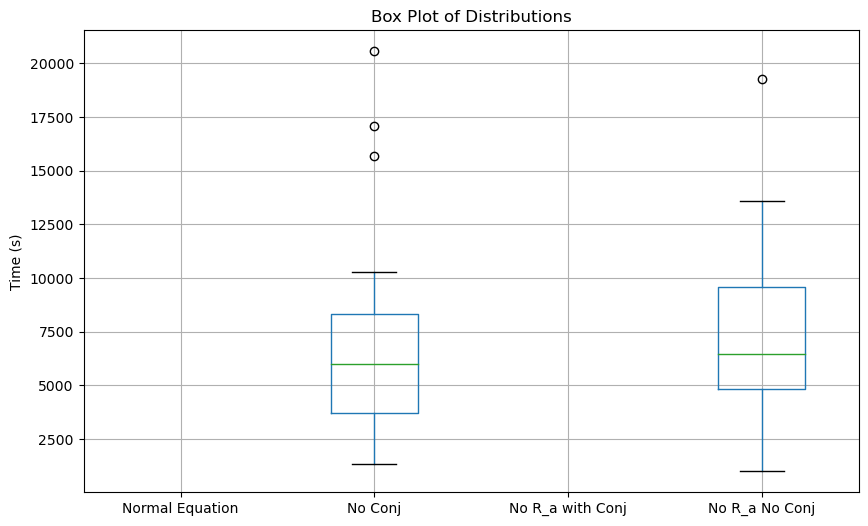

In [5]:
# Step 1: Visualize the Data
plt.figure(figsize=(10, 6))
df.boxplot()
plt.title('Box Plot of Distributions')
plt.ylabel('Time (s)')
plt.show()

### Data Cleaning

In [18]:
# Removing Outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Remove outliers
df_cleaned = df.copy()
df_cleaned['Normal Equation'] = remove_outliers(df, 'Normal Equation')['Normal Equation']
df_cleaned['No Conj'] = remove_outliers(df, 'No Conj')['No Conj']
df_cleaned['No R_a with Conj'] = remove_outliers(df, 'No R_a with Conj')['No R_a with Conj']
df_cleaned['No R_a No Conj'] = remove_outliers(df, 'No R_a No Conj')['No R_a No Conj']
df_cleaned.describe()

,Normal Equation,No Conj,No R_a with Conj,No R_a No Conj
count,0.0,17.000000,0.0,19.000000
mean,NaN,5435.529412,NaN,6991.421053
std,NaN,2634.540902,NaN,3221.604730
min,NaN,1351.000000,NaN,1009.000000
25%,NaN,3162.000000,NaN,4761.000000
50%,NaN,5393.000000,NaN,6322.000000
75%,NaN,8002.000000,NaN,8467.500000
max,NaN,10295.000000,NaN,13580.000000


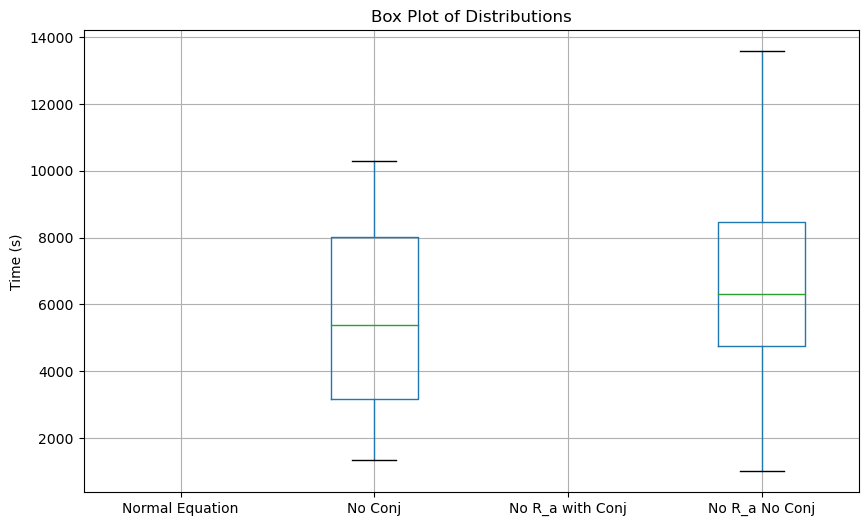

In [13]:
# Visualize the Data
plt.figure(figsize=(10, 6))
df_cleaned.boxplot()
plt.title('Box Plot of Distributions')
plt.ylabel('Time (s)')
plt.show()

### Plotting

<Figure size 1000x600 with 0 Axes>

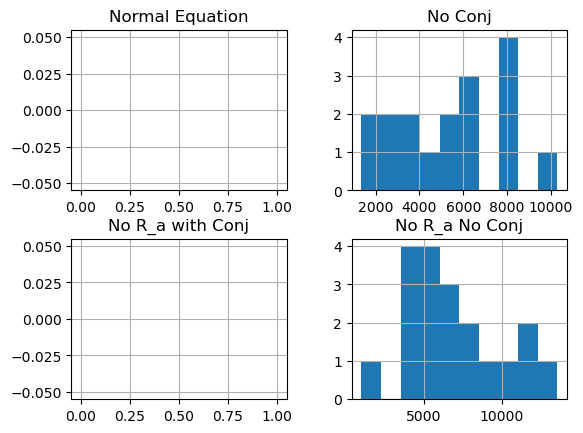

In [16]:
# Visualize the Data
plt.figure(figsize=(10, 6))
df_cleaned.hist()
plt.show()

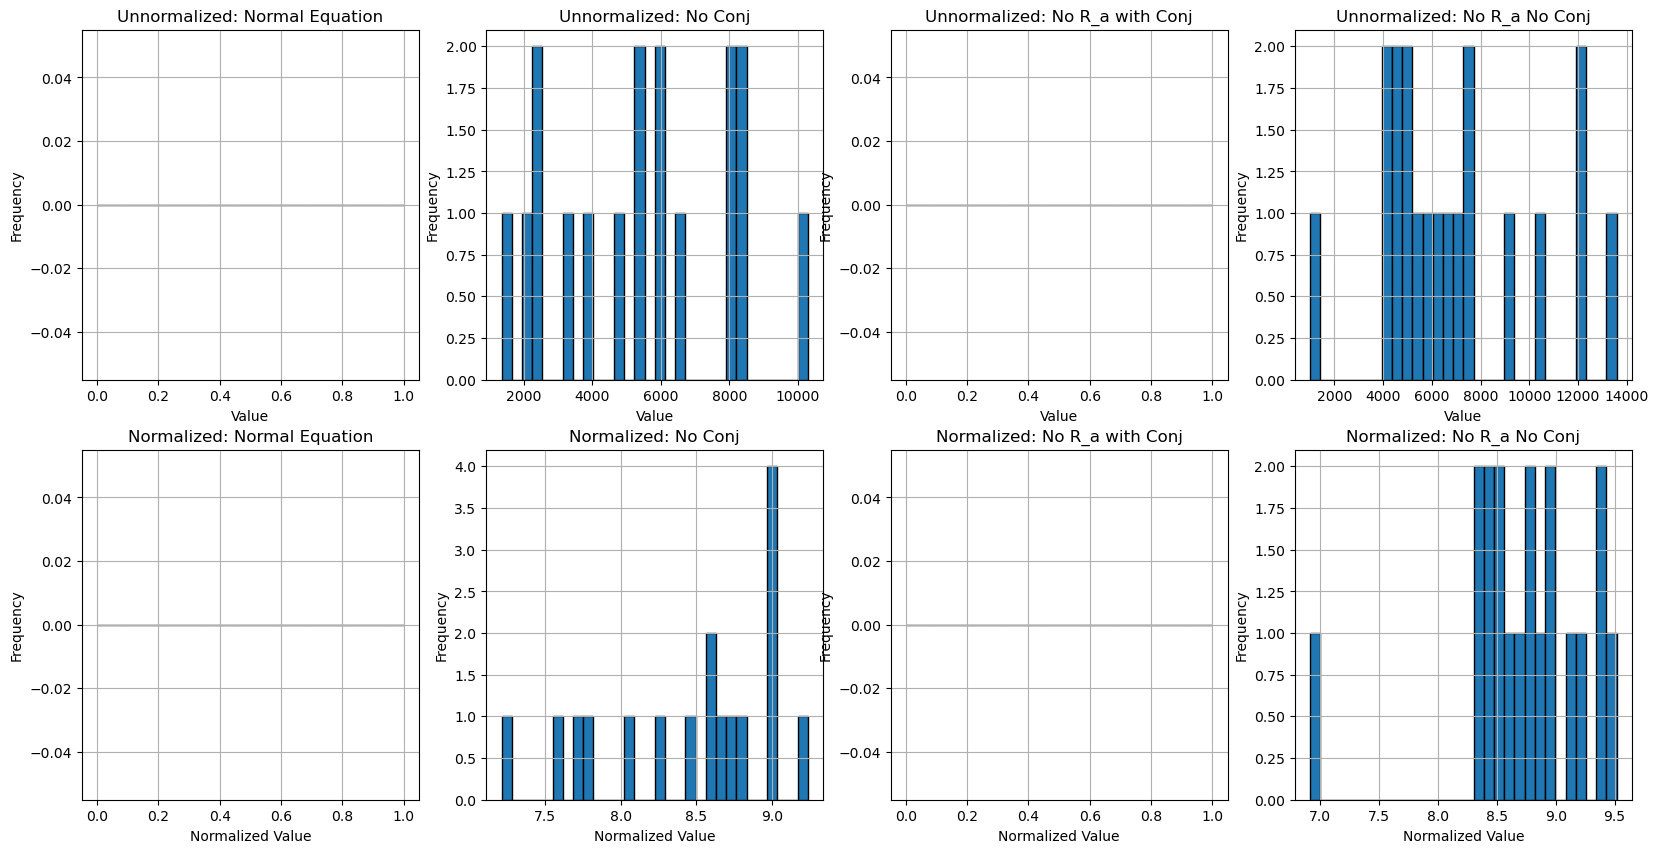

In [15]:
normalized_df_cleaned = df_cleaned.apply(lambda x: np.log(1 + x))
normalized_df_cleaned

# Number of columns to plot
num_columns = len(df_cleaned.columns)

# Create subplots
fig, axs = plt.subplots(2, num_columns, figsize=(5 * num_columns, 10))

# Ensure axs is 2-dimensional, even if there is only one column
if num_columns == 1:
    axs = np.array([[axs[0]], [axs[1]]])

# Plot histograms for each column in unnormalized data
for i, column in enumerate(df_cleaned.columns):
    df_cleaned[column].hist(ax=axs[0, i], bins=30, edgecolor='k')
    axs[0, i].set_title(f'Unnormalized: {column}')
    axs[0, i].set_xlabel('Value')
    axs[0, i].set_ylabel('Frequency')

# Plot histograms for each column in normalized data
for i, column in enumerate(normalized_df_cleaned.columns):
    normalized_df_cleaned[column].hist(ax=axs[1, i], bins=30, edgecolor='k')
    axs[1, i].set_title(f'Normalized: {column}')
    axs[1, i].set_xlabel('Normalized Value')
    axs[1, i].set_ylabel('Frequency')

In [ ]:
# Step 3: Statistical Test
t_stat, p_value = ttest_ind(df['Normal Equation'], df.dropna()['No R_a No Conj'])

print(descriptive_stats)
print(f"t-stat = {t_stat}")
print(f"p value = {p_value}")

In [26]:
# Calculate Skewness of a data set.
skew_normal = skew(df['Normal Equation'])
skew_no_ra_no_conj = skew(df['No R_a No Conj'].dropna())

# Step 3: Mann-Whitney U Test
u_stat, p_value_u = mannwhitneyu(df['Normal Equation'], df['No R_a No Conj'].dropna())

skew_normal, skew_no_ra_no_conj, u_stat, p_value_u

(-0.7637545759696468, 0.27136880449342954, 76.0, 0.30120060673958793)

In [35]:
# Calculate pooled standard deviation
n1 = df.shape[0]
n2 = df['No R_a No Conj'].dropna().shape[0]
s_p = np.sqrt(((n1 - 1) * std_normal**2 + (n2 - 1) * std_no_Ra_no_conj**2) / (n1 + n2 - 2))

# Calculate Cohen's d, (the effect size in power analysis to find required sample size using this sample data).
effect_size = abs(mean_normal - mean_no_Ra_w_conjugation)/s_p

In [36]:
# Perform power analysis
alpha = 0.05
power = 0.80

analysis = smp.NormalIndPower()
required_sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')

effect_size, required_sample_size

(0.11773745591169878, 1132.4194266886839)

In [13]:
# Calculate pooled standard deviation
n1 = n2 = df.shape[0]
s_p = np.sqrt(((n1 - 1) * std_normal**2 + (n2 - 1) * std_no_Ra_w_conjugation**2) / (n1 + n2 - 2))

# Calculate Cohen's d, (the effect size in power analysis to find required sample size using this sample data).
effect_size = abs(mean_normal - mean_no_Ra_w_conjugation)/s_p

Power Analysis Inputs:
- Effect size (Cohen's d): Use the effect size estimated from the pilot study.
- Significance level (α): Typically set at 0.05.
- Power (1 - β): Commonly set at 0.80 or 0.90.
- Two-tailed test: If you are interested in differences in both directions.

In [14]:
# Perform power analysis
alpha = 0.05
power = 0.80

analysis = smp.TTestIndPower()
required_sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')

effect_size, required_sample_size

(0.11875320038300669, 1114.0913828900318)

Given the samples provided, the p-value of 0.709 was higher than the alpha and failed to reject the null hypothesis.  Therefore there was no statistical significant difference between the two distributions.  In order to observe a significant difference, a sample size of around 1114 would be needed.  Therefore the response function showed no significant difference in mutant population fixing.  Both samples included bacterial conjugation.